# 2 site exact solutions

Created 30/04/2025

Objectives:
* Find exact solutions with boundary operators of width 2.

# Package imports

In [1]:
import sys
sys.path.append('../../')

In [2]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os
import pickle

In [3]:
from itertools import chain, combinations
from collections import defaultdict
import re

In [4]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.ticker import AutoMinorLocator, MultipleLocator

In [5]:
from tqdm import tqdm

In [6]:
import quimb as qu
import quimb.tensor as qtn

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


In [7]:
#from SPTOptimization.Optimizers.utils import to_npc_array

# Load data

In [8]:
DATA_DIR = r"../../data/y_transverse_cluster_100_site_dmrg"

In [9]:
loaded_data = list()

for local_file_name in os.listdir(DATA_DIR):
    f_name = r"{}/{}".format(DATA_DIR, local_file_name, ignore_unknown=False)
    with h5py.File(f_name, 'r') as f:
        data = hdf5_io.load_from_hdf5(f)
        loaded_data.append(data)

In [10]:
b_parameters = sorted(list(d['paramters']['t'] for d in loaded_data))

In [11]:
psi_dict = dict()

In [12]:
for b in b_parameters:
    mps_psi = next(
        d['wavefunction']
        for d in loaded_data
        if d['paramters']['t'] == b
    )

    psi_arrays = list()
    psi_arrays.append(mps_psi.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, mps_psi.L-1):
        psi_arrays.append(mps_psi.get_B(i).to_ndarray())
    psi_arrays.append(mps_psi.get_B(mps_psi.L-1)[..., 0].to_ndarray())

    quimb_psi = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    rounded_b = round(b, 1)
    psi_dict[rounded_b] = quimb_psi

# Definitons

In [13]:
MAX_VIRTUAL_BOND_DIM = 8
MAX_INTERMEDIATE_VIRTUAL_BOND_DIM = 2*MAX_VIRTUAL_BOND_DIM
# MPO bond dim?
MAX_MPO_BOND_DIM = 50

SVD_CUTOFF = 1e-3

Define bosonic symmetries. Label by the group element added.

In [14]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Y = np.array([[0,-1j],[1j,0]])
np_Z = np.array([[1,0],[0,-1]])

In [15]:
"""
npc_I = to_npc_array(np_I)
npc_X = to_npc_array(np_X)
npc_Y = to_npc_array(np_Y)
npc_Z = to_npc_array(np_Z)
"""

'\nnpc_I = to_npc_array(np_I)\nnpc_X = to_npc_array(np_X)\nnpc_Y = to_npc_array(np_Y)\nnpc_Z = to_npc_array(np_Z)\n'

In [16]:
symmetry_actions = [
    [np_I, np_I],
    [np_I, np_X],
    [np_X, np_I],
    [np_X, np_X]
]

In [17]:
def generate_problem_rdm(quimb_psi, symmetry_site_pairs, leftmost_symmetry_site,
                         num_symmetry_sites, num_boundary_sites,
                         antilinear=False):
    # Being careful to conjugate the top tensors.
    q_top = quimb_psi.copy(deep=True)

    for i, s in symmetry_site_pairs:
        if antilinear:
            q_top[i].modify(
                data=q_top[i].data.conj()
            )

        q_top.gate(
            s,
            where=i,
            contract=False,
            inplace=True
        )

    left_boundary_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        leftmost_symmetry_site
    ))

    right_boundary_sites = list(range(
        leftmost_symmetry_site+num_symmetry_sites,
        leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites
    ))
    
    indices_to_map = list(chain(left_boundary_sites, right_boundary_sites))

    index_mapping = {f'k{i}': f'b{i}' for i in indices_to_map}

    q_bottom = (
        quimb_psi
        .copy()
        .reindex(index_mapping, inplace=True)
        .conj()
    )

    sites_to_contract = {
        'left': list(range(leftmost_symmetry_site-num_boundary_sites)),
        'middle': list(range(leftmost_symmetry_site, leftmost_symmetry_site+num_symmetry_sites)),
        'right': list(range(leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites, quimb_psi.L))
    }

    tags_to_contract = {
        k: [f'I{i}' for i in v]
        for k, v in sites_to_contract.items()
    }

    tn = (q_top & q_bottom)

    """
    tnc = (
        tn
        .contract(tags_to_contract['left'])
        .contract(tags_to_contract['middle'])
        .contract(tags_to_contract['right'])
    )
    """

    tnc = tn.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_boundary_sites)),
        ('b_left', (f'b{i}' for i in left_boundary_sites)),
        ('k_right', (f'k{i}' for i in right_boundary_sites)),
        ('b_right', (f'b{i}' for i in right_boundary_sites))
    ]

    tnc.fuse(fuse_maps, inplace=True)

    return tnc

## Optimisation functions

In [18]:
def solve_for_boundary_operators(rdm, num_iters=20):
    scores = list()

    u_left = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['k_left', 'b_left'],
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['k_right', 'b_right'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_rdm = (rdm & u_left).contract()
        data = right_rdm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds = ['b_right', 'k_right'])
        
        left_rdm = (rdm & u_right).contract()
        data = left_rdm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds = ['b_left', 'k_left'])

    return (u_left, u_right), scores

## SPT functions

In [19]:
def calculate_proj_rep_phase(state_g, left_schmidt_values_g, unitary_h,
                             state_gh,
                             left_environment,
                             max_virtual_bond_dim=MAX_VIRTUAL_BOND_DIM):
    prod_state, _ = multiply_stacked_unitaries_against_mps(
        unitary_h,
        state_g,
        left_schmidt_values_g,
        max_virtual_bond_dim
    )

    exp = inner_product_b_tensors(prod_state, state_gh, left_environment)

    return exp/(np.abs(exp))

In [20]:
def get_proj_rep_phases(mps_tensors, left_schmidt_values, unitaries,
                        left_environment):
    mps_dict = {
        k: v for k, v in zip(symmetry_labels[1:], mps_tensors)
    }

    schmidt_vals_dict = {
        k: v for k, v in zip(symmetry_labels[1:], left_schmidt_values)
    }

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    out_phases = list()

    for a, b, c in group_products:
        phase = calculate_proj_rep_phase(
            mps_dict[a],
            schmidt_vals_dict[a],
            unitaries_dict[b],
            mps_dict[c],
            left_environment,
            max_virtual_bond_dim=MAX_VIRTUAL_BOND_DIM
        )

        out_phases.append(phase)

    return out_phases

In [21]:
def get_right_proj_rep_phases_from_optimizers(optimizers):
    mps_tensors = [
        o.top_right_mps_tensors
        for o in optimizers[1:]
    ]

    left_schmidt_values = [
        o.current_right_side_left_schmidt_values
        for o in optimizers[1:]
    ]

    unitaries = [
        o.right_unitaries for o in optimizers[1:]
    ]

    left_environment = optimizers[0].right_side_left_symmetry_environment

    out = get_proj_rep_phases(
        mps_tensors,
        left_schmidt_values,
        unitaries,
        left_environment
    )

    return out

In [22]:
def get_left_proj_rep_phases_from_optimizers(optimizers):
    mps_tensors = [
        o.top_left_mps_tensors
        for o in optimizers[1:]
    ]

    left_schmidt_values = [
        o.current_left_side_right_schmidt_values
        for o in optimizers[1:]
    ]

    unitaries = [
        o.left_unitaries for o in optimizers[1:]
    ]

    left_environment = optimizers[0].left_side_right_symmetry_environment

    out = get_proj_rep_phases(
        mps_tensors,
        left_schmidt_values,
        unitaries,
        left_environment
    )

    return out

# Calculate boundary operators
## Exterior

In [70]:
num_boundary_sites=2
leftmost_symmetry_site=30
num_symmetry_sites=40

symmetry_sites = list(range(
    leftmost_symmetry_site,
    leftmost_symmetry_site+num_symmetry_sites
))

In [71]:
num_iterations = 3

In [72]:
results_dict = dict()

for k, psi in tqdm(psi_dict.items()):
    symmetry_site_pairs = [(i, np_X) for i in symmetry_sites]

    rdm = generate_problem_rdm(
        psi,
        symmetry_site_pairs,
        leftmost_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites,
        antilinear=True
    )

    (u_left, u_right), scores = solve_for_boundary_operators(
        rdm,
        num_iters=num_iterations
    )

    results_dict[k] = (u_left, u_right), scores

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 19.48it/s]


## Check results

In [73]:
t_params = np.round(np.linspace(0, 1, 21), 1)

In [74]:
t_params

array([0. , 0. , 0.1, 0.2, 0.2, 0.2, 0.3, 0.4, 0.4, 0.4, 0.5, 0.6, 0.6,
       0.6, 0.7, 0.8, 0.8, 0.8, 0.9, 1. , 1. ])

In [75]:
scores = list()
for t in t_params:

    scores.append(results_dict[t][1][-1])

scores = np.array(scores)

In [76]:
scores.shape

(21,)

In [78]:
exterior_scores = scores

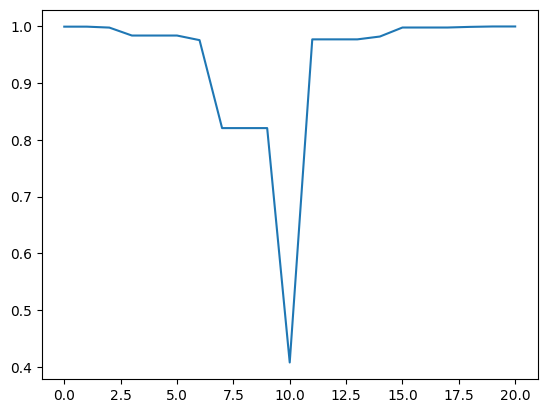

In [79]:
plt.plot(exterior_scores)

Ok, so getting sensible boundary operators out.

In [80]:
proj_rep_phases = list()

for t in t_params:
    psi = psi_dict[t]

    rdm = generate_problem_rdm(
        psi,
        [],
        leftmost_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites,
        antilinear=False
    )

    left_rdm = (
        rdm
        .trace('b_right', 'k_right')
        .transpose('k_left', 'b_left')
        .data
    )
    right_rdm = (
        rdm
        .trace('b_left', 'k_left')
        .transpose('k_right', 'b_right')
        .data
    )

    left_unitary, right_unitary = results_dict[t][0]

    left_unitary = (
        left_unitary
        .transpose('b_left', 'k_left')
        .data
    )

    right_unitary = (
        right_unitary
        .transpose('b_right', 'k_right')
        .data
    )

    left_phase = np.trace(
        left_rdm
        @ left_unitary
        @ left_unitary
    )/(np.trace(left_rdm))

    right_phase = np.trace(
        right_rdm
        @ right_unitary
        @ right_unitary
    )/(np.trace(right_rdm))

    proj_rep_phases.append([left_phase, right_phase])

In [81]:
proj_rep_phases = np.array(proj_rep_phases)

In [82]:
proj_rep_phases.shape

(21, 2)

In [83]:
proj_rep_phases

array([[ 0.68668212+0.72695782j,  0.92170498-0.38789164j],
       [ 0.68668212+0.72695782j,  0.92170498-0.38789164j],
       [-0.14253874+0.98978922j,  0.83098168-0.55629978j],
       [-0.31670473+0.94852418j, -0.38575264-0.92260224j],
       [-0.31670473+0.94852418j, -0.38575264-0.92260224j],
       [-0.31670473+0.94852418j, -0.38575264-0.92260224j],
       [ 0.38191177-0.92419879j, -0.08912146-0.99602076j],
       [ 0.99233753+0.12345633j, -0.56399856+0.82577576j],
       [ 0.99233753+0.12345633j, -0.56399856+0.82577576j],
       [ 0.99233753+0.12345633j, -0.56399856+0.82577576j],
       [ 0.70253285+0.71113806j,  0.70789864-0.70627495j],
       [ 0.94997149+0.01753641j,  0.99618983-0.02287089j],
       [ 0.94997149+0.01753641j,  0.99618983-0.02287089j],
       [ 0.94997149+0.01753641j,  0.99618983-0.02287089j],
       [ 0.7518125 +0.60911679j,  0.76939013-0.6142059j ],
       [ 0.39044739+0.92034286j,  0.39013208-0.9205681j ],
       [ 0.39044739+0.92034286j,  0.39013208-0.9205681j 

In [84]:
proj_rep_phases = list()

for t in t_params:
    psi = psi_dict[t]

    rdm = generate_problem_rdm(
        psi,
        [],
        leftmost_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites,
        antilinear=False
    )

    left_rdm = (
        rdm
        .trace('b_right', 'k_right')
        .transpose('k_left', 'b_left')
        .data
    )
    right_rdm = (
        rdm
        .trace('b_left', 'k_left')
        .transpose('k_right', 'b_right')
        .data
    )

    left_unitary, right_unitary = results_dict[t][0]

    left_unitary = (
        left_unitary
        .transpose('b_left', 'k_left')
        .data
    )

    right_unitary = (
        right_unitary
        .transpose('b_right', 'k_right')
        .data
    )

    left_phase = np.trace(
        left_rdm
        @ np.conj(left_unitary)
        @ left_unitary
    )/(np.trace(left_rdm))

    right_phase = np.trace(
        right_rdm
        @ np.conj(right_unitary)
        @ right_unitary
    )/(np.trace(right_rdm))

    proj_rep_phases.append([left_phase, right_phase])

In [85]:
proj_rep_phases = np.array(proj_rep_phases)

In [86]:
proj_rep_phases.shape

(21, 2)

In [87]:
proj_rep_phases

array([[-0.9992264 +5.91188007e-12j, -0.9944793 +5.02531849e-12j],
       [-0.9992264 +5.91188007e-12j, -0.9944793 +5.02531849e-12j],
       [ 0.75940564-9.54604612e-10j,  0.20909883+2.77513682e-09j],
       [-0.31458347-1.94640188e-06j,  0.45857842-1.81598870e-07j],
       [-0.31458347-1.94640188e-06j,  0.45857842-1.81598870e-07j],
       [-0.31458347-1.94640188e-06j,  0.45857842-1.81598870e-07j],
       [ 0.90070673-3.58437135e-06j, -0.96400338+3.14156459e-06j],
       [-0.36475275-1.32497581e-03j,  0.99685204+1.91934435e-05j],
       [-0.36475275-1.32497581e-03j,  0.99685204+1.91934435e-05j],
       [-0.36475275-1.32497581e-03j,  0.99685204+1.91934435e-05j],
       [-0.9997441 -2.84796600e-03j, -0.99996652+3.31659508e-03j],
       [ 0.25747045+9.14665840e-01j,  0.90673025-3.08086725e-01j],
       [ 0.25747045+9.14665840e-01j,  0.90673025-3.08086725e-01j],
       [ 0.25747045+9.14665840e-01j,  0.90673025-3.08086725e-01j],
       [ 0.08204273+9.64068554e-01j,  0.49394557-8.31192355e-0

## Interior boundary operators

In [88]:
def generate_problem_rdm(quimb_psi, symmetry_site_pairs, leftmost_symmetry_site,
                         num_symmetry_sites, num_boundary_sites,
                         antilinear=False, interior=False):
    # Being careful to conjugate the top tensors.
    q_top = quimb_psi.copy(deep=True)

    for i, s in symmetry_site_pairs:
        if antilinear:
            q_top[i].modify(
                data=q_top[i].data.conj()
            )
        q_top.gate(
            s,
            where=i,
            contract=False,
            inplace=True
        )

    shift = num_boundary_sites if interior else False
    left_boundary_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites + shift,
        leftmost_symmetry_site+shift
    ))

    right_boundary_sites = list(range(
        leftmost_symmetry_site+num_symmetry_sites-shift,
        leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites-shift
    ))
    
    indices_to_map = list(chain(left_boundary_sites, right_boundary_sites))

    index_mapping = {f'k{i}': f'b{i}' for i in indices_to_map}

    q_bottom = (
        quimb_psi
        .copy()
        .reindex(index_mapping, inplace=True)
        .conj()
    )

    sites_to_contract = {
        'left': list(range(leftmost_symmetry_site-num_boundary_sites+shift)),
        'middle': list(range(leftmost_symmetry_site+shift, leftmost_symmetry_site+num_symmetry_sites-shift)),
        'right': list(range(leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites-shift, quimb_psi.L))
    }

    tags_to_contract = {
        k: [f'I{i}' for i in v]
        for k, v in sites_to_contract.items()
    }

    tn = (q_top & q_bottom)

    """
    tnc = (
        tn
        .contract(tags_to_contract['left'])
        .contract(tags_to_contract['middle'])
        .contract(tags_to_contract['right'])
    )
    """

    tnc = tn.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_boundary_sites)),
        ('b_left', (f'b{i}' for i in left_boundary_sites)),
        ('k_right', (f'k{i}' for i in right_boundary_sites)),
        ('b_right', (f'b{i}' for i in right_boundary_sites))
    ]

    tnc.fuse(fuse_maps, inplace=True)

    return tnc

In [89]:
results_dict = dict()

for k, psi in tqdm(psi_dict.items()):
    symmetry_site_pairs = [(i, np_X) for i in symmetry_sites]

    rdm = generate_problem_rdm(
        psi,
        symmetry_site_pairs,
        leftmost_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites,
        antilinear=True,
        interior=True
    )

    (u_left, u_right), scores = solve_for_boundary_operators(
        rdm,
        num_iters=num_iterations
    )

    results_dict[k] = (u_left, u_right), scores

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 22.07it/s]


In [90]:
scores = list()
for t in t_params:

    scores.append(results_dict[t][1][-1])

scores = np.array(scores)

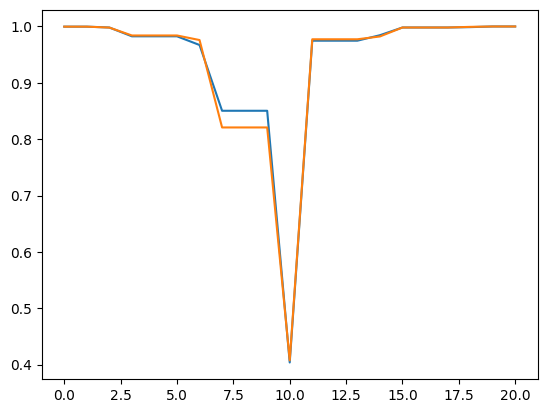

In [91]:
plt.plot(scores)
plt.plot(exterior_scores)

Close, but slightly different. That's what we want to see.

In [92]:
proj_rep_phases = list()

for t in t_params:
    psi = psi_dict[t]

    rdm = generate_problem_rdm(
        psi,
        [],
        leftmost_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites,
        antilinear=False
    )

    left_rdm = (
        rdm
        .trace('b_right', 'k_right')
        .transpose('k_left', 'b_left')
        .data
    )
    right_rdm = (
        rdm
        .trace('b_left', 'k_left')
        .transpose('k_right', 'b_right')
        .data
    )

    left_unitary, right_unitary = results_dict[t][0]

    left_unitary = (
        left_unitary
        .transpose('b_left', 'k_left')
        .data
    )

    right_unitary = (
        right_unitary
        .transpose('b_right', 'k_right')
        .data
    )

    left_phase = np.trace(
        left_rdm
        @ left_unitary
        @ left_unitary
    )/(np.trace(left_rdm))

    right_phase = np.trace(
        right_rdm
        @ right_unitary
        @ right_unitary
    )/(np.trace(right_rdm))

    proj_rep_phases.append([left_phase, right_phase])

In [93]:
proj_rep_phases = np.array(proj_rep_phases)

In [94]:
proj_rep_phases

array([[ 0.83393135+0.55186819j,  0.98574259-0.16826035j],
       [ 0.83393135+0.55186819j,  0.98574259-0.16826035j],
       [-0.50079375-0.86556665j, -0.99698945-0.0775373j ],
       [-0.8724558 -0.48869303j, -0.83406286+0.55166941j],
       [-0.8724558 -0.48869303j, -0.83406286+0.55166941j],
       [-0.8724558 -0.48869303j, -0.83406286+0.55166941j],
       [-0.36763729+0.92996926j,  0.073782  +0.99727439j],
       [ 0.95647953-0.29174534j, -0.85169325+0.52404045j],
       [ 0.95647953-0.29174534j, -0.85169325+0.52404045j],
       [ 0.95647953-0.29174534j, -0.85169325+0.52404045j],
       [-0.84408053+0.5358003j , -0.84109703-0.54075985j],
       [ 0.82245537+0.54572093j,  0.82212628-0.53556515j],
       [ 0.82245537+0.54572093j,  0.82212628-0.53556515j],
       [ 0.82245537+0.54572093j,  0.82212628-0.53556515j],
       [-0.48684413+0.86228784j, -0.49882994-0.83664725j],
       [-0.74162535-0.67074886j, -0.74203454+0.66886842j],
       [-0.74162535-0.67074886j, -0.74203454+0.66886842j

In [95]:
np_X_2 = np.kron(np_X, np_X)

In [96]:
proj_rep_phases = list()

for t in t_params:
    psi = psi_dict[t]

    rdm = generate_problem_rdm(
        psi,
        [],
        leftmost_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites,
        antilinear=False
    )

    left_rdm = (
        rdm
        .trace('b_right', 'k_right')
        .transpose('k_left', 'b_left')
        .data
    )
    right_rdm = (
        rdm
        .trace('b_left', 'k_left')
        .transpose('k_right', 'b_right')
        .data
    )

    left_unitary, right_unitary = results_dict[t][0]

    left_unitary = (
        left_unitary
        .transpose('b_left', 'k_left')
        .data
    )

    right_unitary = (
        right_unitary
        .transpose('b_right', 'k_right')
        .data
    )

    left_phase = np.trace(
        left_rdm
        @ np_X_2
        @ np.conj(left_unitary)
        @ np_X_2
        @ left_unitary
    )/(np.trace(left_rdm))

    right_phase = np.trace(
        right_rdm
        @ np_X_2
        @ np.conj(right_unitary)
        @ np_X_2
        @ right_unitary
    )/(np.trace(right_rdm))

    proj_rep_phases.append([left_phase, right_phase])

In [97]:
proj_rep_phases = np.array(proj_rep_phases)

In [98]:
proj_rep_phases

array([[-1.        -2.03426915e-18j, -1.        -2.03426915e-18j],
       [-1.        -2.03426915e-18j, -1.        -2.03426915e-18j],
       [-1.        -1.24370982e-17j, -1.        -1.24370982e-17j],
       [-1.        -2.38310637e-17j, -1.        -1.68921698e-17j],
       [-1.        -2.38310637e-17j, -1.        -1.68921698e-17j],
       [-1.        -2.38310637e-17j, -1.        -1.68921698e-17j],
       [-1.        +2.46624447e-16j, -1.        -1.70535216e-17j],
       [-1.        +1.73699713e-16j, -1.        -8.99782558e-17j],
       [-1.        +1.73699713e-16j, -1.        -8.99782558e-17j],
       [-1.        +1.73699713e-16j, -1.        -8.99782558e-17j],
       [ 0.99999836+6.34895749e-14j,  0.99998417+9.66158546e-14j],
       [ 1.        -4.60347862e-18j,  1.        -8.94028731e-18j],
       [ 1.        -4.60347862e-18j,  1.        -8.94028731e-18j],
       [ 1.        -4.60347862e-18j,  1.        -8.94028731e-18j],
       [ 1.        +3.59628909e-18j,  1.        -2.93634570e-1

In [99]:
proj_rep_phases = list()

for t in t_params:
    psi = psi_dict[t]

    rdm = generate_problem_rdm(
        psi,
        [],
        leftmost_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites,
        antilinear=False
    )

    left_rdm = (
        rdm
        .trace('b_right', 'k_right')
        .transpose('k_left', 'b_left')
        .data
    )
    right_rdm = (
        rdm
        .trace('b_left', 'k_left')
        .transpose('k_right', 'b_right')
        .data
    )

    left_unitary, right_unitary = results_dict[t][0]

    left_unitary = (
        left_unitary
        .transpose('b_left', 'k_left')
        .data
    )

    right_unitary = (
        right_unitary
        .transpose('b_right', 'k_right')
        .data
    )

    left_phase = np.trace(
        left_rdm
        @ np.conj(left_unitary)
        @ left_unitary
    )/(np.trace(left_rdm))

    right_phase = np.trace(
        right_rdm
        @ np.conj(right_unitary)
        @ right_unitary
    )/(np.trace(right_rdm))

    proj_rep_phases.append([left_phase, right_phase])

In [100]:
proj_rep_phases = np.array(proj_rep_phases)

In [101]:
proj_rep_phases

array([[-0.99922626+5.94289693e-12j, -0.99448088+5.25235216e-12j],
       [-0.99922626+5.94289693e-12j, -0.99448088+5.25235216e-12j],
       [ 0.75967034-3.30394137e-10j,  0.20844193+6.14548017e-10j],
       [-0.31340759-8.28617737e-07j,  0.45645059-3.08930173e-08j],
       [-0.31340759-8.28617737e-07j,  0.45645059-3.08930173e-08j],
       [-0.31340759-8.28617737e-07j,  0.45645059-3.08930173e-08j],
       [ 0.89885698-5.68982084e-08j, -0.96323078+1.35214316e-06j],
       [-0.39684934-1.21003535e-03j,  0.99713498+6.35234377e-05j],
       [-0.39684934-1.21003535e-03j,  0.99713498+6.35234377e-05j],
       [-0.39684934-1.21003535e-03j,  0.99713498+6.35234377e-05j],
       [-0.99976248-1.18107980e-02j, -0.99979912+1.34093193e-02j],
       [ 0.74838849+5.87447184e-01j,  0.7984361 -5.70255483e-01j],
       [ 0.74838849+5.87447184e-01j,  0.7984361 -5.70255483e-01j],
       [ 0.74838849+5.87447184e-01j,  0.7984361 -5.70255483e-01j],
       [ 0.71058882+6.60367107e-01j, -0.45911194-8.58979821e-0

# Conclusions
So it looks like there is one right way to do this.
* Take internal (to the symmetry) defect operators.
* Apply Kapustin index.
What if we used the Else-Nayak index?